# Phase 2: Data Preprocessing

## Objectives

In this phase, you will:

1. Load the cleaned dataset from Phase 1
2. Encode categorical variables for model compatibility
3. Analyze and handle skewness in numerical features
4. Apply appropriate scaling techniques
5. Prepare separate train and test datasets
6. Create a fully preprocessed dataset ready for feature engineering

## Instructions

Complete each task in order. This notebook builds on the cleaned data from Phase 1.

---
## Task 1: Import Libraries and Load Cleaned Data

In [22]:
# TODO: Import necessary libraries
# - pandas, numpy, matplotlib.pyplot, seaborn
# - from scipy import stats
# - from sklearn.preprocessing import: LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

# TODO: Set pandas display options
# - display.max_columns to None
# - display.max_rows to 100

# TODO: Print success message

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Success!")

Success!


In [23]:
# TODO: Load cleaned data from Phase 1
# - Read 'train_cleaned.csv' using pd.read_csv()
# - Store in variable 'df'

df = pd.read_csv('train_cleaned.csv')

# TODO: Print dataset information
# - Dataset shape
# - Total missing values
# - Display first few rows with .head()

print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isnull().sum().sum())
print("First 5 rows:", df.head())



Dataset Shape: (1460, 76)
Total Missing Values: 1201
First 5 rows:    Id  MSSubClass MSZoning  LotFrontage  LotArea Street LotShape LandContour  \
0   1          60       RL         65.0     8450   Pave      Reg         Lvl   
1   2          20       RL         80.0     9600   Pave      Reg         Lvl   
2   3          60       RL         68.0    11250   Pave      IR1         Lvl   
3   4          70       RL         60.0     9550   Pave      IR1         Lvl   
4   5          60       RL         84.0    14260   Pave      IR1         Lvl   

  Utilities LotConfig LandSlope Neighborhood Condition1 Condition2 BldgType  \
0    AllPub    Inside       Gtl      CollgCr       Norm       Norm     1Fam   
1    AllPub       FR2       Gtl      Veenker      Feedr       Norm     1Fam   
2    AllPub    Inside       Gtl      CollgCr       Norm       Norm     1Fam   
3    AllPub    Corner       Gtl      Crawfor       Norm       Norm     1Fam   
4    AllPub       FR2       Gtl      NoRidge       Norm  

---
## Task 2: Separate Features and Target

Separate the target variable (SalePrice) from the features for preprocessing.

In [24]:
# TODO: Separate target variable from features
# - Create 'y' = copy of 'SalePrice' column
# - Create 'X' = dataframe without 'SalePrice'

# TODO: Drop 'Id' column from X if it exists (not useful for modeling)
# - Check if 'Id' in X.columns
# - If yes, drop it

# TODO: Print information
# - Features shape (X.shape)
# - Target shape (y.shape)
# - Target statistics (y.describe())

y = df["SalePrice"].copy()
X = df.drop('SalePrice', axis=1)

if ('Id' in X.columns):
    X = X.drop('Id', axis=1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Target statistics:")
print(y.describe())

Features shape: (1460, 74)
Target shape: (1460,)
Target statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


---
## Task 3: Identify Feature Types for Encoding

Categorize features and determine appropriate encoding strategies.

In [25]:
# TODO: Identify feature types
# - Categorical: X.select_dtypes(include=['object']).columns.tolist()
# - Numerical: X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# TODO: Print lists with counts

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical: ")
print(len(cat_cols))
print(cat_cols)

print()

print("Numerical: ")
print(len(num_cols))
print(num_cols)

Categorical: 
38
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']

Numerical: 
36
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', '

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9820\3328457169.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object']).columns.tolist()


In [26]:
# TODO: Analyze categorical features cardinality
# - Loop through categorical_features
# - For each column, print name and number of unique values
# - Use .nunique() to count unique values

for col in cat_cols:
    cnt = X[col].nunique()
    print(col, ":", cnt, "unique values")

MSZoning : 5 unique values
Street : 2 unique values
LotShape : 4 unique values
LandContour : 4 unique values
Utilities : 2 unique values
LotConfig : 5 unique values
LandSlope : 3 unique values
Neighborhood : 25 unique values
Condition1 : 9 unique values
Condition2 : 8 unique values
BldgType : 5 unique values
HouseStyle : 8 unique values
RoofStyle : 6 unique values
RoofMatl : 8 unique values
Exterior1st : 15 unique values
Exterior2nd : 16 unique values
ExterQual : 4 unique values
ExterCond : 5 unique values
Foundation : 6 unique values
BsmtQual : 4 unique values
BsmtCond : 4 unique values
BsmtExposure : 4 unique values
BsmtFinType1 : 6 unique values
BsmtFinType2 : 6 unique values
Heating : 6 unique values
HeatingQC : 5 unique values
CentralAir : 2 unique values
Electrical : 5 unique values
KitchenQual : 4 unique values
Functional : 7 unique values
FireplaceQu : 5 unique values
GarageType : 6 unique values
GarageFinish : 3 unique values
GarageQual : 5 unique values
GarageCond : 5 unique 

---
## Task 4: Encode Categorical Variables

### Encoding Strategy:

1. **Ordinal Features** (with natural order): Use Label Encoding or manual mapping
   - Examples: Quality ratings (Ex, Gd, TA, Fa, Po), Condition ratings
   
2. **Nominal Features** (no natural order): Use One-Hot Encoding
   - Examples: Neighborhood, Building Type, Exterior Type
   
3. **High Cardinality Features** (>10 unique values): Consider frequency encoding or target encoding (advanced)

Refer to `data_description.txt` to identify ordinal features.

### Step 4.1: Identify Ordinal vs Nominal Features

Review the data description and categorize your features.

In [27]:
# TODO: Define ordinal features and their order
# Review data_description.txt to identify ordinal features
# Example ordinal pattern for quality ratings: Po=1, Fa=2, TA=3, Gd=4, Ex=5


# 
# Create ordinal_mappings dictionary with:
# - Quality features (ExterQual, ExterCond, etc.)
# - Condition features
# - Other ordinal features from data dictionary

# TODO: Separate features into ordinal and nominal
# - ordinal_features: list of ordinal feature names
# - nominal_features: categorical features not in ordinal list

# TODO: Print counts and names of ordinal and nominal features



shape_map = {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1}
exter_qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
exter_cond_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
bsmt_qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
bsmt_cond_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'NA': 0, np.nan: 0}
bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4,'Rec': 3,'LwQ': 2,'Unf': 1, 'NA': 0,  np.nan: 0}
heating_qc_map   = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
kitchen_qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
fireplace_qu_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
garage_qual_map  = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
garage_cond_map  = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
pool_qc_map      = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0, np.nan: 0}
fence_map = {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'NA': 0, np.nan: 0}
slope_map = {'Gtl': 3, 'Mod': 2, 'Sev': 1}
gar_fin_map = {'Fin': 3, 'RFn': 2, 'Unf': 1, 'NA': 0, np.nan: 0}
paved_map = {'Y': 3, 'P': 2, 'N': 1}
func_map = {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1}


ordinal_mappings = {
    'LotShape': shape_map,
    'ExterQual': exter_qual_map,
    'ExterCond': exter_cond_map,
    'BsmtQual': bsmt_qual_map,
    'BsmtCond': bsmt_cond_map,
    'BsmtExposure': bsmt_exposure_map,
    'BsmtFinType1': bsmt_fin_map,
    'BsmtFinType2': bsmt_fin_map,
    'HeatingQC': heating_qc_map,
    'KitchenQual': kitchen_qual_map,
    'FireplaceQu': fireplace_qu_map,
    'GarageQual': garage_qual_map,
    'GarageCond': garage_cond_map,
    'PoolQC': pool_qc_map,
    'Fence': fence_map,
    'LandSlope': slope_map,
    'GarageFinish': gar_fin_map,
    'PavedDrive': paved_map,
    'Functional': func_map
}


ordinal_features = [col for col in ordinal_mappings.keys() if col in cat_cols]
nominal_features = [col for col in cat_cols if col not in ordinal_features]

print("Ordinal:", len(ordinal_features))
print(ordinal_features)
print()

print("Nominal:", len(nominal_features))
print(nominal_features)
print()

Ordinal: 17
['LotShape', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'LandSlope', 'GarageFinish', 'PavedDrive', 'Functional']

Nominal: 21
['MSZoning', 'Street', 'LandContour', 'Utilities', 'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'Foundation', 'Heating', 'CentralAir', 'Electrical', 'GarageType', 'SaleType', 'SaleCondition']



### Step 4.2: Apply Ordinal Encoding

In [28]:
# TODO: Create a copy for encoding
# X_encoded = X.copy()

# TODO: Apply ordinal encoding
# - Loop through ordinal_mappings
# - Map each feature using .map() method
# - Print confirmation for each encoded feature

# TODO: Verify encoding
# - Display head of ordinal features to verify the mapping worked correctly

X_encoded = X.copy()

for col, mp in ordinal_mappings.items():
    if col in X_encoded.columns:
        X_encoded[col] = X_encoded[col].map(mp)
        print("Encoded: ", col)

display(X_encoded[ordinal_features].head())

Encoded:  LotShape
Encoded:  ExterQual
Encoded:  ExterCond
Encoded:  BsmtQual
Encoded:  BsmtCond
Encoded:  BsmtExposure
Encoded:  BsmtFinType1
Encoded:  BsmtFinType2
Encoded:  HeatingQC
Encoded:  KitchenQual
Encoded:  FireplaceQu
Encoded:  GarageQual
Encoded:  GarageCond
Encoded:  LandSlope
Encoded:  GarageFinish
Encoded:  PavedDrive
Encoded:  Functional


,LotShape,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,LandSlope,GarageFinish,PavedDrive,Functional
0,4,4,3,4,3,1,6,1,5,4,0,3,3,3,2,3,8
1,4,3,3,4,3,4,5,1,5,3,3,3,3,3,2,3,8
2,3,4,3,4,3,2,6,1,5,4,3,3,3,3,2,3,8
3,3,3,3,3,4,1,5,1,4,4,4,3,3,3,1,3,8
4,3,4,3,4,3,3,6,1,5,4,3,3,3,3,2,3,8


### Step 4.3: Apply One-Hot Encoding to Nominal Features

In [29]:
# TODO: Apply one-hot encoding to nominal features
# - Check if nominal_features list is not empty
# - Use pd.get_dummies() with:
#   * columns=nominal_features
#   * drop_first=True (to avoid multicollinearity)
# - Print new shape and feature count


if(len(nominal_features) > 0):
    X_encoded = pd.get_dummies(X_encoded, columns=nominal_features, drop_first=True)


print("New Shape: ", X_encoded.shape)
print("New Feature Count: ", X_encoded.shape[1])

New Shape:  (1460, 190)
New Feature Count:  190


In [30]:
# TODO: Display sample of encoded dataset
# - Print message
# - Show first few rows of X_encoded

print("Sample of Encoded Dataset:")
display(X_encoded.head())

Sample of Encoded Dataset:


,MSSubClass,LotFrontage,LotArea,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,4,3,7,5,2003,2003,196.0,4,3,4,3,1,6,706,1,0,150,856,5,856,854,0,1710,1,0,2,1,3,1,4,8,8,0,0,2003.0,2,2,548,3,3,3,0,61,0,0,0,0,0,2,2008,False,False,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,4,3,6,8,1976,1976,0.0,3,3,4,3,4,5,978,1

---
## Task 5: Analyze Distribution and Skewness

Examine the distribution of numerical features and identify highly skewed features.

In [31]:
# TODO: Calculate skewness for all numerical features
# - Select numerical columns using select_dtypes
# - Apply stats.skew() to each column
# - Create DataFrame with Feature and Skewness columns
# - Sort by absolute skewness in descending order
# - Print top 20 most skewed features

# TODO: Identify highly skewed features
# - Filter features with |skewness| > 0.75
# - Store in highly_skewed list
# - Print count and list of highly skewed features


num_colls = X_encoded.select_dtypes(include=['int64', 'float64']).columns

skew = X_encoded[num_colls].apply(stats.skew)

df3 = pd.DataFrame({
    'Feature': skew.index,
    'Skewness': skew.values
})

df3 = df3.sort_values(by='Skewness', ascending=False)

print("Top 20 most skewed features:")
print(df3.head(20))


highly_skewed = df3[df3['Skewness'] > 0.75]['Feature'].tolist()

print()
print("Count:", len(highly_skewed))
print("Highly Skewed Features:")
print(highly_skewed)




Top 20 most skewed features:
          Feature   Skewness
50        MiscVal  24.451640
49       PoolArea  14.813135
2         LotArea  12.195142
47      3SsnPorch  10.293752
24   LowQualFinSF   9.002080
31   KitchenAbvGr   4.483784
18     BsmtFinSF2   4.250888
48    ScreenPorch   4.117977
27   BsmtHalfBath   4.099186
17   BsmtFinType2   3.293608
46  EnclosedPorch   3.086696
9      MasVnrArea   2.674865
1     LotFrontage   2.406671
45    OpenPorchSF   2.361912
16     BsmtFinSF1   1.683771
44     WoodDeckSF   1.539792
20    TotalBsmtSF   1.522688
0      MSSubClass   1.406210
11      ExterCond   1.395783
22       1stFlrSF   1.375342

Count: 25
Highly Skewed Features:
['MiscVal', 'PoolArea', 'LotArea', '3SsnPorch', 'LowQualFinSF', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch', 'BsmtHalfBath', 'BsmtFinType2', 'EnclosedPorch', 'MasVnrArea', 'LotFrontage', 'OpenPorchSF', 'BsmtFinSF1', 'WoodDeckSF', 'TotalBsmtSF', 'MSSubClass', 'ExterCond', '1stFlrSF', 'GrLivArea', 'BsmtExposure', 'BsmtUnfSF', '

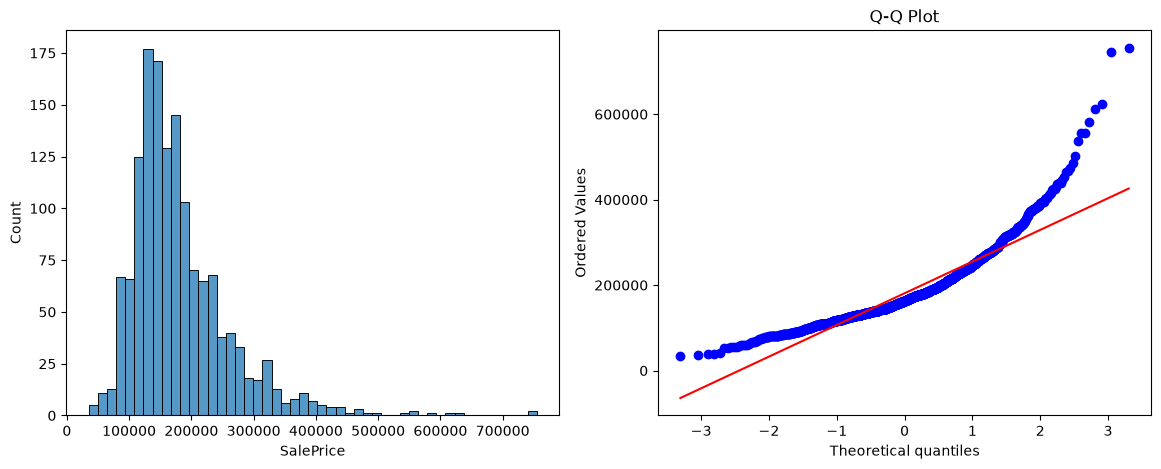

SalePrice Skewness:  1.8828757597682129


In [32]:
# TODO: Visualize distribution of target variable
# - Create 1x2 subplot figure (figsize=(14, 5))
# - Left plot: Histogram of SalePrice with skewness in title
# - Right plot: Q-Q plot using stats.probplot()
# - Display the plots

skeww = df['SalePrice'].skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['SalePrice'],ax=axes[0])
plt.title("SalePrice Skewness")

stats.probplot(df['SalePrice'], plot=axes[1])
plt.title("Q-Q Plot")
plt.show()

# TODO: Print target variable skewnes

print("SalePrice Skewness: ", skeww)

---
## Task 6: Handle Skewness

Apply transformations to reduce skewness in highly skewed features.

**Common transformations:**
- Log transformation: `log1p(x)` - good for right-skewed data
- Square root: `sqrt(x)` - moderate right skewness
- Box-Cox: Automatic optimal transformation (requires positive values)

**When to apply:**
- Right-skewed (positive skewness > 0.75): Use log transformation
- Left-skewed (negative skewness < -0.75): Consider reflection + log

### Step 6.1: Transform Target Variable

If the target variable is skewed, transform it for better model performance.

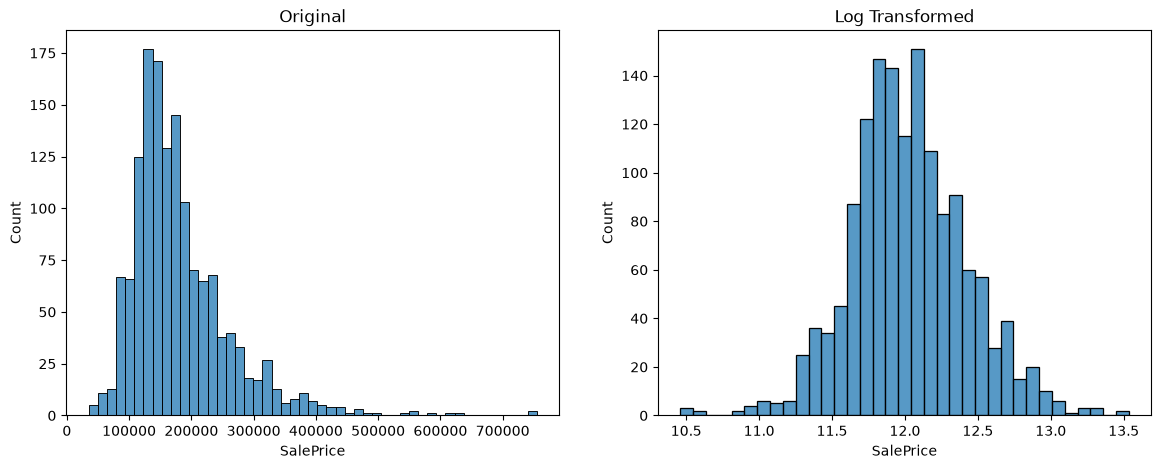

Before: 1.8828757597682129
After: 0.12134661989685333


In [33]:
# TODO: Check if target needs transformation
# - Calculate target skewness
# - If |skewness| > 0.75:
#   * Apply log transformation using np.log1p()
#   * Calculate new skewness
#   * Create side-by-side plots comparing original and transformed
#   * Print before and after skewness values
# - Else: Keep original target and print message


target_sk = y.skew()

if(abs(target_sk) > 0.75):
    y_transformed = np.log1p(y)
    new_sk = y_transformed.skew()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(y, ax=axes[0])
    axes[0].set_title("Original")

    sns.histplot(y_transformed, ax=axes[1])
    axes[1].set_title("Log Transformed")

    plt.show()

    print("Before:", target_sk)
    print("After:", new_sk)
else:
    y_transformed = y.copy()
    print("No transformation needed")
    

### Step 6.2: Transform Highly Skewed Features

In [34]:
# TODO: Apply log transformation to highly skewed features
# - Create copy of X_encoded as X_transformed
# - Loop through highly_skewed features:
#   * Check if all values are non-negative
#   * Apply np.log1p() transformation
#   * Print before and after skewness for each feature
# - Print completion message


X_transformed = X_encoded.copy()

for i in highly_skewed:
    if((X_transformed[i] >= 0).all()):
        old = X_transformed[i].skew()
        X_transformed[i] = np.log1p( X_transformed[i])
        new = X_transformed[i].skew()

        print(i, " Before: ", old, " After: ", new)

print("Completed!")

MiscVal  Before:  24.476794188821916  After:  5.170703861673264
PoolArea  Before:  14.828373640750588  After:  14.363102459725052
LotArea  Before:  12.207687851233496  After:  -0.13740448122837784
3SsnPorch  Before:  10.304342032693112  After:  7.734974870241933
LowQualFinSF  Before:  9.011341288465387  After:  7.460316514621369
KitchenAbvGr  Before:  4.488396777072859  After:  3.8694137036546494
BsmtFinSF2  Before:  4.255261108933303  After:  2.5236937641679753
ScreenPorch  Before:  4.122213743143115  After:  3.150408862444581
BsmtHalfBath  Before:  4.103402697955168  After:  3.9330635244650436
BsmtFinType2  Before:  3.296996417042157  After:  1.8635872062914827
EnclosedPorch  Before:  3.08987190371177  After:  2.1122749483873156
MasVnrArea  Before:  2.6776164510820997  After:  0.5035317177020202
LotFrontage  Before:  2.4091466665496006  After:  -0.870005697584457
OpenPorchSF  Before:  2.3643417403694404  After:  -0.02339729485739231
BsmtFinSF1  Before:  1.685503071910789  After:  -0.

---
## Task 7: Feature Scaling

Apply appropriate scaling to numerical features.

**Scaling methods:**
1. **StandardScaler**: Mean=0, StdDev=1 (good for normally distributed data)
2. **MinMaxScaler**: Scale to [0,1] range (good for bounded distributions)
3. **RobustScaler**: Uses median and IQR (robust to outliers)

**When to use:**
- StandardScaler: Most common, works well after skewness correction
- RobustScaler: When outliers are present and important
- MinMaxScaler: When feature range matters (e.g., neural networks)

In [35]:
# TODO: Get numerical columns after transformation
# - Select numerical columns from X_transformed
# - Store in numeric_features list
# - Print count of features to scale

numeric_features = X_transformed.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Count of numeric features to scale:", len(numeric_features))

Count of numeric features to scale: 53


### Step 7.1: Choose and Apply Scaling Method

Select a scaling method and apply it to numerical features.

In [36]:
# TODO: Create a copy for scaling
# X_scaled = X_transformed.copy()

# TODO: Choose and initialize scaling method
# - StandardScaler() - recommended after log transformation
# - RobustScaler() - alternative if outliers are important
# - MinMaxScaler() - alternative for bounded range

# TODO: Apply scaling to numerical features
# - Use fit_transform() on numeric_features
# - Print scaler name and scaled statistics

X_scaled = X_transformed.copy()

scaler = StandardScaler()

X_scaled[numeric_features] = scaler.fit_transform(X_scaled[numeric_features])

print("Standart Scaler")
print(X_scaled[numeric_features].describe)

Standart Scaler
<bound method NDFrame.describe of       MSSubClass  LotFrontage   LotArea  LotShape  LandSlope  OverallQual  \
0       0.424462    -0.078896 -0.133270  0.701291   0.225716     0.651479   
1      -1.125202     0.572719  0.113413  0.701291   0.225716    -0.071836   
2       0.424462     0.062541  0.420049 -1.016637   0.225716     0.651479   
3       0.645073    -0.329561  0.103317 -1.016637   0.225716     0.651479   
4       0.424462     0.726089  0.878431 -1.016637   0.225716     1.374795   
...          ...          ...       ...       ...        ...          ...   
1455    0.424462    -0.226913 -0.259231  0.701291   0.225716    -0.071836   
1456   -1.125202     0.763303  0.725429  0.701291   0.225716    -0.071836   
1457    0.645073    -0.031048 -0.002359  0.701291   0.225716     0.651479   
1458   -1.125202     0.062541  0.136833  0.701291   0.225716    -0.795151   
1459   -1.125202     0.369988  0.180116  0.701291   0.225716    -0.795151   

      OverallCond  YearBu

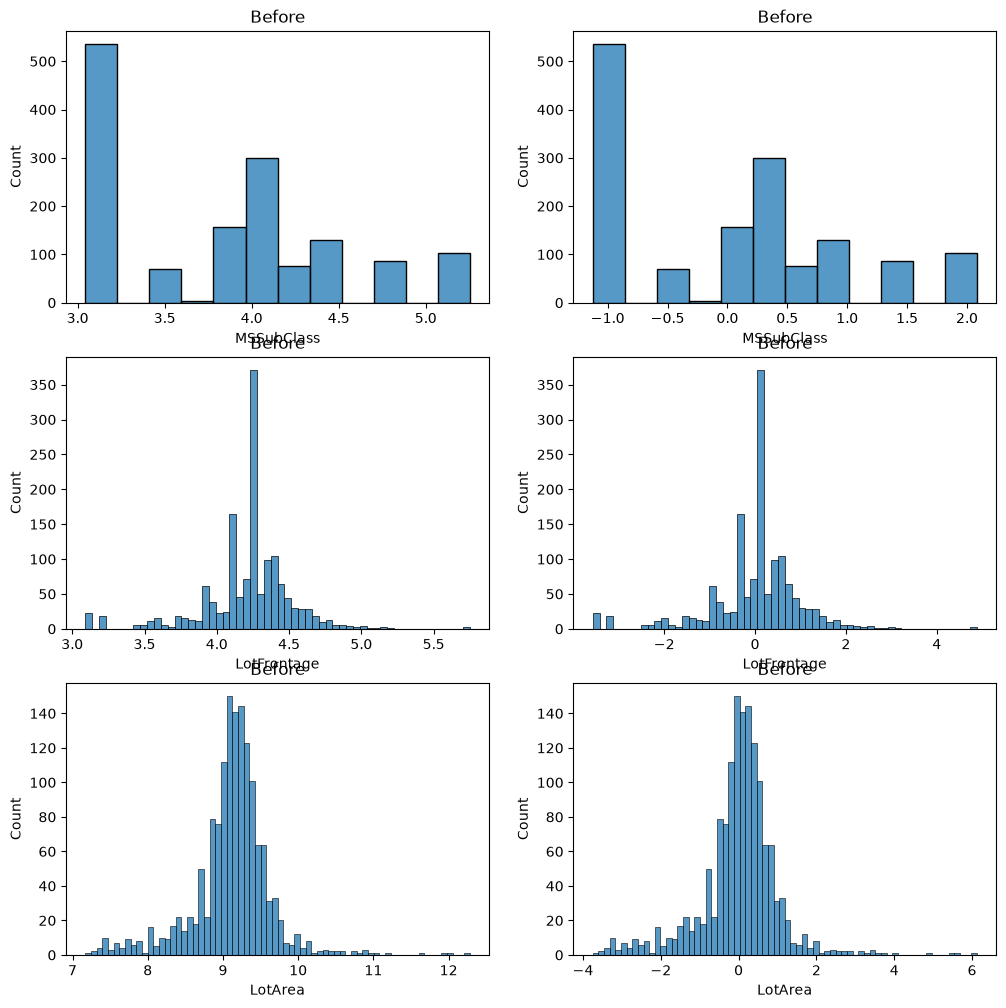

In [37]:
# TODO: Visualize effect of scaling
# - Select first 3 numerical features as samples
# - Create subplots (rows = number of features, columns = 2)
# - For each feature:
#   * Left: histogram before scaling
#   * Right: histogram after scaling
# - Display the comparison plots


sample_features = numeric_features[:3]

fig, axes = plt.subplots(len(sample_features), 2, figsize=(12, 4 * len(sample_features)))

for i, col in enumerate(sample_features):
    sns.histplot(X_transformed[col], ax = axes[i, 0])   
    axes[i, 0].set_title('Before')

    sns.histplot(X_scaled[col], ax = axes[i, 1])   
    axes[i, 1].set_title('Before')



plt.show()

---
## Task 8: Process Test Dataset

Apply the same preprocessing steps to the test dataset.

**Important:** Use the same transformations and scaling parameters from the training set.

In [38]:
# TODO: Load test dataset
# - Read 'test.csv'
# - Print shape and missing value count

test_df = pd.read_csv('test.csv')

print('Shape: ', test_df.shape)
print('Missing value count: ', test_df.isnull().sum().sum())

# TODO: Save test IDs for later submission
# - Extract and save 'Id' column

test_id = test_df['Id']

# TODO: Drop 'Id' column from test_df

test_df = test_df.drop('Id', axis=1)

Shape:  (1459, 80)
Missing value count:  7878


### Step 8.1: Apply Same Cleaning and Encoding to Test Data

Replicate your Phase 1 cleaning steps and encoding from this notebook.

**Key considerations:**
- Handle missing values using same strategy
- Apply same feature drops
- Use same encoding mappings

In [39]:
# TODO: Apply same preprocessing steps to test data
# CRITICAL: Use same transformations as training data
# 
# Steps to replicate:
# 1. Handle missing values (same strategy as training)
# 2. Drop same features
# 3. Apply same ordinal encoding (use same mappings)
# 4. Apply same one-hot encoding (same columns)
# 5. Apply same transformations (log transform same features)
# 6. Apply same scaling (use scaler.transform(), NOT fit_transform())

# Your implementation here


features_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType"]
test_df = test_df.drop(columns=[col for col in features_to_drop if col in test_df.columns])


none_cols = ["FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "BsmtQual", "BsmtCond"]
for col in none_cols:
    if (col in test_df.columns):
        test_df[col] = test_df[col].fillna("None")

test_df["Electrical"] = test_df["Electrical"].fillna(df["Electrical"].mode()[0])


test_df["LotFrontage"] = test_df["LotFrontage"].fillna(df["LotFrontage"].median())
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(0)
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(0)


for col, mp in ordinal_mappings.items():
    if (col in test_df.columns):
        test_df[col] = test_df[col].map(mp)
        test_df[col] = test_df[col].fillna(0)


test_encoded = pd.get_dummies(test_df, columns=nominal_features, drop_first=True)
test_encoded = test_encoded.reindex(columns=X_encoded.columns, fill_value=0)


for feature in highly_skewed:
    if feature in test_encoded.columns and (test_encoded[feature] >= 0).all():
        test_encoded[feature] = np.log1p(test_encoded[feature])


test_scaled = test_encoded.copy()
test_scaled[numeric_features] = scaler.transform(test_scaled[numeric_features])


print("Final Shape:", test_scaled.shape)


Final Shape: (1459, 190)


---
## Task 9: Final Verification and Save

Verify preprocessing is complete and save the datasets.

In [40]:
# TODO: Final verification - Print summary statistics
# Training Set:
#   - Shape
#   - Missing value count
#   - Data types distribution
# 
# Target Variable:
#   - Shape
#   - Range (min, max)
#   - Skewness
#
# TODO: Verify all features are numeric (no object types remain)


print("Training Set:")
print("Shape:", X_scaled.shape)
print("Missing value count:", X_scaled.isnull().sum().sum())
print("Data Types Distribution:")
print(X_scaled.dtypes.value_counts())

print("------------------------------------------------")

print("Target Variable:")
print("Shape:", y_transformed.shape)
print("Range: min =", y_transformed.min(), ", max =", y_transformed.max())
print("Skewness:", stats.skew(y_transformed))

print("------------------------------------------------")

non_numeric = X_scaled.select_dtypes(include=['object']).columns.tolist()

if len(non_numeric) == 0:
    print("Nice!")
else:
    print("Bad!")


Training Set:
Shape: (1460, 190)
Missing value count: 0
Data Types Distribution:
bool       137
float64     53
Name: count, dtype: int64
------------------------------------------------
Target Variable:
Shape: (1460,)
Range: min = 10.460270761075149 , max = 13.534474352733596
Skewness: 0.12122191311528367
------------------------------------------------
Nice!


In [43]:
# TODO: Save preprocessed datasets
# - Save X_scaled to 'train_preprocessed.csv' (index=False)
# - Save y_transformed to 'train_target.csv' as DataFrame with 'SalePrice' column
# - Print confirmation messages with file names

X_scaled.to_csv('train_preprocessed.csv', index=False)
print("Features successfully saved to 'train_preprocessed.csv'")

pd.DataFrame({'SalePrice': y_transformed}).to_csv('train_target.csv', index=False)
print("Target variable successfully saved to 'train_target.csv'")

Features successfully saved to 'train_preprocessed.csv'
Target variable successfully saved to 'train_target.csv'


---
## Summary and Reflection

### What You Accomplished:

1. Loaded cleaned data from Phase 1
2. Separated features and target variable
3. Encoded categorical variables (ordinal and one-hot encoding)
4. Analyzed and reduced skewness in numerical features
5. Applied appropriate scaling to numerical features
6. Preprocessed test dataset with same transformations
7. Created model-ready datasets

### Key Questions for Reflection:

1. How many features do you have after one-hot encoding? 190.
2. Which encoding method did you use for ordinal features and why? Ordinal mapping. To preserve the natural hierarchy and order so the model understands the relative rankings.
3. How much did skewness reduce after transformation? ~0.12.
4. Which scaling method did you choose and why? StandardScaler. To keep numerical features on the same scale and stop larger metrics from biasing the model.
5. How did you ensure test data preprocessing matched training data?  I am sure both datasets were processed using the exact same steps and rules

### Important Notes:

- Save your scaler object if you need to inverse transform predictions later
- If you log-transformed the target, remember to inverse transform predictions: `np.expm1(predictions)`
- Keep track of feature names after one-hot encoding for interpretation

### Next Steps:

Proceed to **Phase 3: Feature Engineering** where you will:
- Create new features from existing ones
- Combine related features
- Extract domain-specific features
- Reduce dimensionality if needed